# Introduction to Unsupervised Learning

**Audience:** Students with basic Python, NumPy, Matplotlib, and introductory machine learning background.

## Learning Goals

By the end of this notebook, students should be able to:

- Explain what unsupervised learning means
- Compare supervised and unsupervised learning
- Use PCA for dimensionality reduction
- Use K-means clustering
- Use hierarchical clustering
- Use DBSCAN clustering
- Interpret clustering results visually

---

## 0. Setup

In [3]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_blobs, make_moons, load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score

np.random.seed(0)

---

## 1. What Is Unsupervised Learning?

In **supervised learning**, the training data include labels.

Examples:

- image → cat/dog
- student data → pass/fail
- material features → phase label

In **unsupervised learning**, the data do not have labels.

The goal is to discover hidden structure, such as:

- clusters
- low-dimensional patterns
- outliers
- similarity relationships


---

## 2. Generate a Simple Dataset

We create a synthetic dataset with natural clusters. In a real unsupervised learning problem, these labels would not be known.


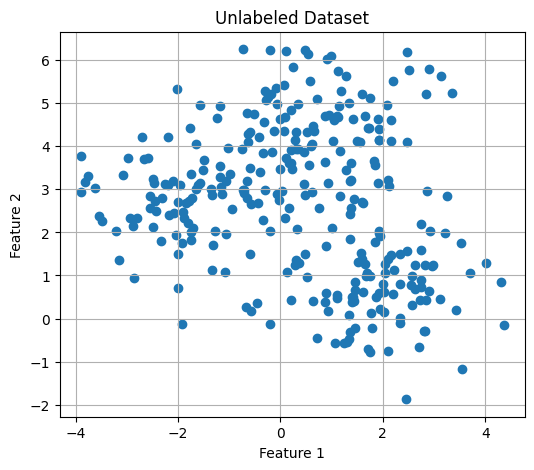

In [6]:
X, true_labels = make_blobs(
    n_samples=300,
    centers=3,
    cluster_std=1.0,
    random_state=0
)

plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1])
plt.xlabel("Feature 1")

plt.ylabel("Feature 2")
plt.title("Unlabeled Dataset")
plt.grid(True)
plt.show()

---

## 3. K-Means Clustering

K-means tries to divide data into `k` groups.

Basic idea:

1. Choose cluster centers
2. Assign each point to the nearest center
3. Update the centers
4. Repeat


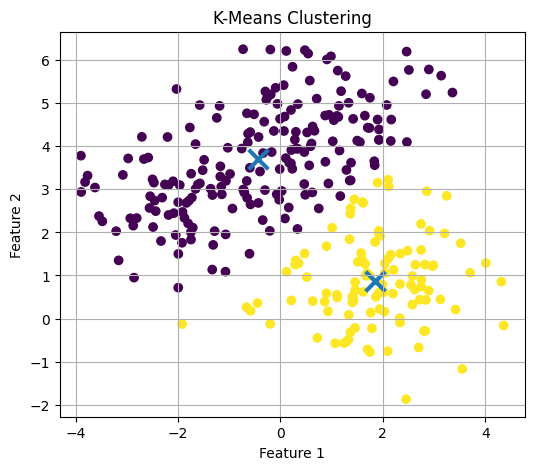

In [10]:
kmeans = KMeans(n_clusters=2, random_state=0, n_init=10)
pred_labels = kmeans.fit_predict(X)

plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], c=pred_labels)
plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    marker="x",
    s=200,
    linewidths=3
)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("K-Means Clustering")
plt.grid(True)
plt.show()

---

## 4. Choosing the Number of Clusters: Elbow Method

The K-means objective is called **inertia**.

A smaller inertia means points are closer to their cluster centers, but using too many clusters can overfit.


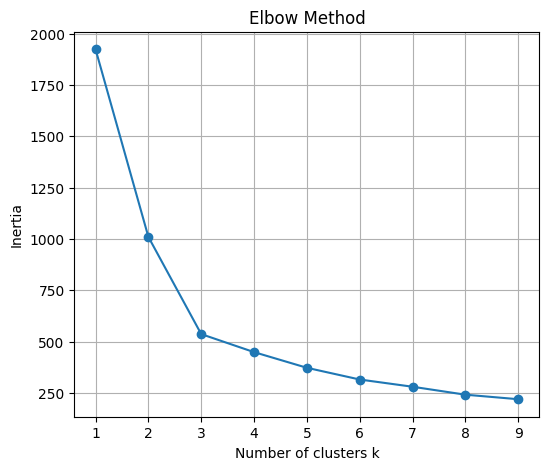

In [12]:
inertias = []

K_values = range(1, 10)

for k in K_values:
    model = KMeans(n_clusters=k, random_state=0, n_init=10)
    model.fit(X)
    inertias.append(model.inertia_)

plt.figure(figsize=(6, 5))
plt.plot(K_values, inertias, marker="o")
plt.xlabel("Number of clusters k")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.grid(True)
plt.show()

Look for an “elbow” where improvement begins to slow down.

---

## 5. Silhouette Score

The silhouette score measures how well-separated clusters are.

- Close to 1: well-separated clusters
- Around 0: overlapping clusters
- Negative: likely incorrect assignments


In [14]:
score = silhouette_score(X, pred_labels)
print("Silhouette score:", score)

Silhouette score: 0.44582632494402635


### Load the Iris Dataset

The Iris dataset has 4 features. We will ignore the labels and use PCA to reduce the data to 2 dimensions.


In [16]:
iris = load_iris()
X_iris = iris.data
feature_names = iris.feature_names

print("Shape of X_iris:", X_iris.shape)
print("Feature names:")
for name in feature_names:
    print("-", name)

Shape of X_iris: (150, 4)
Feature names:
- sepal length (cm)
- sepal width (cm)
- petal length (cm)
- petal width (cm)


### Standardize the Data

PCA is sensitive to feature scaling, so standardization is usually important.


In [18]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_iris)


print("Original shape:", X_scaled.shape)


Original shape: (150, 4)


---

## 7. PCA + K-Means

Now we apply K-means to the PCA-reduced Iris data.


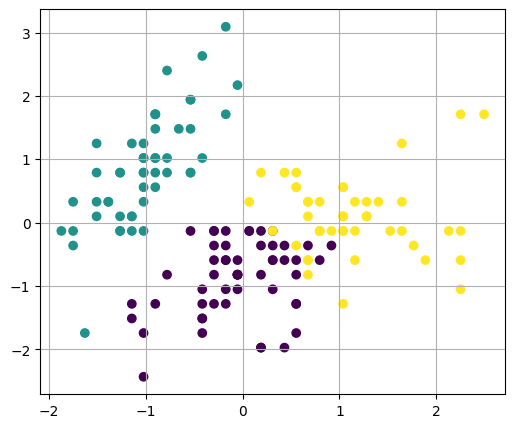

In [24]:
kmeans_iris = KMeans(n_clusters=3, random_state=0, n_init=10)
iris_clusters = kmeans_iris.fit_predict(X_scaled)

plt.figure(figsize=(6, 5))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=iris_clusters)

plt.grid(True)
plt.show()

